# Facial Emotion Recognition
**Binary classification**: `neutral` vs `happy`  
**Embeddings**: CLIP (`openai/clip-vit-base-patch32`) and SigLIP2 (`google/siglip2-base-patch16-224`)  
**Classifiers**: Logistic Regression (linear probe), XGBoost, Deep Probe (3-layer MLP)

In [1]:
# mount the drive to read the data
# Change the runtime type to T4 GPU at first
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import os
from pathlib import Path

# Google Drive path of the dataset
DATA_DIR = Path("/content/gdrive/MyDrive/AffectiveComputing/training_set")
ANN_PATH = DATA_DIR / "annotations.csv"
dataset_path = str(DATA_DIR)

# Check if the directory exists
if not os.path.exists(dataset_path):
    print(f"Error: Dataset path '{dataset_path}' not found. Please ensure Google Drive is mounted correctly and the path is accurate.")
else:
    # List the contents of the dataset directory
    print(f"Contents of '{dataset_path}':")
    # for item in os.listdir(dataset_path):

Contents of '/content/gdrive/MyDrive/AffectiveComputing/training_set':


In [3]:
import pandas as pd
import os

annotations_path = os.path.join(dataset_path, 'annotations.csv')

# Reload the CSV, assuming no header initially, then rename columns
df_annotations = pd.read_csv(annotations_path, header=None)

# Assign meaningful column names based on the content observed in the previous output
df_annotations.columns = ['image_name', 'label']

print("Annotations reloaded with correct headers. Displaying head of the DataFrame:")
print(df_annotations.head())

Annotations reloaded with correct headers. Displaying head of the DataFrame:
  image_name    label
0     1a.JPG  neutral
1     2a.JPG  neutral
2     3a.JPG  neutral
3     4a.JPG  neutral
4     5a.JPG  neutral


In [4]:
# Cell 1: Install dependencies (run once, comment out after)
import subprocess, sys

packages = [
    "torch", "torchvision",
    "transformers", "accelerate",
    "scikit-learn", "xgboost",
    "Pillow", "pandas",
    "matplotlib", "seaborn",
    "umap-learn",
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("All packages installed.")

All packages installed.


In [5]:
# Cell 2: Imports & configuration
import os
import re
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
from transformers import (
    CLIPModel, CLIPProcessor,
    AutoModel, AutoProcessor,
)

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.base import clone
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.manifold import TSNE

# ── Reproducibility & paths ──────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {DEVICE}")
print(f"Data dir exists: {DATA_DIR.exists()}")

Device : cuda
Data dir exists: True


In [6]:
# Cell 3: Data loading + subject-aware train/val/test split

# ── Load annotations ─────────────────────────────────────────────────────────
df = pd.read_csv(ANN_PATH, header=None, names=["filename", "label"])
print(f"Total rows: {len(df)}")
print(df["label"].value_counts())

# ── Resolve .JPG → .jpg (case-insensitive lookup) ────────────────────────────
actual_files = {f.lower(): f for f in os.listdir(DATA_DIR) if f.lower().endswith(".jpg")}
df["resolved_filename"] = df["filename"].apply(lambda x: actual_files.get(x.lower()))
missing = df["resolved_filename"].isna().sum()
print(f"Missing matches: {missing}")  # should be 0

# ── Extract subject ID (strip trailing 'a' / 'b') ────────────────────────────
def extract_subject_id(filename):
    stem = Path(filename).stem           # e.g. "42a", "S3b"
    return re.sub(r'[ab]$', '', stem)    # e.g. "42",  "S3"

df["subject_id"] = df["filename"].apply(extract_subject_id)
print(f"Unique subjects: {df['subject_id'].nunique()}")  # expect 250

# ── Subject-stratified split (70 / 15 / 15) ──────────────────────────────────
subjects = df["subject_id"].unique()
subjects_train, subjects_temp = train_test_split(subjects, test_size=0.30, random_state=SEED)
subjects_val,   subjects_test = train_test_split(subjects_temp, test_size=0.50, random_state=SEED)

train_df = df[df["subject_id"].isin(subjects_train)].reset_index(drop=True)
val_df   = df[df["subject_id"].isin(subjects_val)].reset_index(drop=True)
test_df  = df[df["subject_id"].isin(subjects_test)].reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("Train label dist:", train_df["label"].value_counts().to_dict())

# Verify no subject leaks across splits
assert set(subjects_train) & set(subjects_val)  == set(), "Subject leak: train / val"
assert set(subjects_train) & set(subjects_test) == set(), "Subject leak: train / test"
assert set(subjects_val)   & set(subjects_test) == set(), "Subject leak: val / test"
print("Split integrity check passed.")

Total rows: 500
label
neutral    250
happy      250
Name: count, dtype: int64
Missing matches: 0
Unique subjects: 250
Train: 350 | Val: 74 | Test: 76
Train label dist: {'neutral': 175, 'happy': 175}
Split integrity check passed.


In [7]:
# Cell 4: Load CLIP and SigLIP2 embedding models

print("Loading CLIP (openai/clip-vit-base-patch32)...")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE).eval()
print(f"  CLIP loaded — embed dim: 512")

print("Loading SigLIP2 (google/siglip2-base-patch16-224)...")
siglip_processor = AutoProcessor.from_pretrained("google/siglip2-base-patch16-224")
siglip_model     = AutoModel.from_pretrained("google/siglip2-base-patch16-224").to(DEVICE).eval()
print(f"  SigLIP2 loaded — embed dim: 768")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading CLIP (openai/clip-vit-base-patch32)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/253 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

  SigLIP2 loaded — embed dim: 768


In [8]:
# Cell 5: Embedding extraction

LABEL_MAP = {"neutral": 0, "happy": 1}

def extract_embeddings(df, data_dir, processor, model, model_type, device, batch_size=32):
    """
    Extract L2-normalised image embeddings using CLIP or SigLIP2.

    Parameters
    ----------
    model_type : "clip" | "siglip"

    Returns
    -------
    embeddings : np.ndarray, shape (n_samples, embed_dim)
    labels     : np.ndarray, shape (n_samples,)
    """
    all_embs, all_labels = [], []

    with torch.no_grad():
        for start in range(0, len(df), batch_size):
            batch = df.iloc[start : start + batch_size]
            images = [
                Image.open(data_dir / row.resolved_filename).convert("RGB")
                for _, row in batch.iterrows()
            ]
            inputs = processor(images=images, return_tensors="pt").to(device)

            if model_type == "clip":
                embs = model.get_image_features(**inputs)          # (B, 512)
            else:  # siglip
                embs = model.vision_model(**inputs).pooler_output  # (B, 768)

            # L2-normalise → embeddings live on the unit hypersphere
            embs = embs / embs.norm(dim=-1, keepdim=True)
            all_embs.append(embs.cpu().float().numpy())
            all_labels.extend([LABEL_MAP[r.label] for _, r in batch.iterrows()])

    return np.vstack(all_embs), np.array(all_labels)


print("Extracting CLIP embeddings...")
X_clip_train, y_train = extract_embeddings(train_df, DATA_DIR, clip_processor, clip_model, "clip", DEVICE)
X_clip_val,   _       = extract_embeddings(val_df,   DATA_DIR, clip_processor, clip_model, "clip", DEVICE)
X_clip_test,  y_test  = extract_embeddings(test_df,  DATA_DIR, clip_processor, clip_model, "clip", DEVICE)

print("Extracting SigLIP2 embeddings...")
X_sig_train, _ = extract_embeddings(train_df, DATA_DIR, siglip_processor, siglip_model, "siglip", DEVICE)
X_sig_val,   _ = extract_embeddings(val_df,   DATA_DIR, siglip_processor, siglip_model, "siglip", DEVICE)
X_sig_test,  _ = extract_embeddings(test_df,  DATA_DIR, siglip_processor, siglip_model, "siglip", DEVICE)

print(f"CLIP   — train: {X_clip_train.shape}, val: {X_clip_val.shape}, test: {X_clip_test.shape}")
print(f"SigLIP2 — train: {X_sig_train.shape}, val: {X_sig_val.shape}, test: {X_sig_test.shape}")

# Sanity-check: norms should all be ≈ 1.0
clip_norms = np.linalg.norm(X_clip_train, axis=1)
print(f"CLIP embedding norms — mean: {clip_norms.mean():.4f}, std: {clip_norms.std():.4f}")

Extracting CLIP embeddings...
Extracting SigLIP2 embeddings...
CLIP   — train: (350, 512), val: (74, 512), test: (76, 512)
SigLIP2 — train: (350, 768), val: (74, 768), test: (76, 768)
CLIP embedding norms — mean: 1.0000, std: 0.0000


In [9]:
# Cell 6: Define classifiers

classifiers = {
    "LogReg (linear probe)": LogisticRegression(
        C=0.1,            # regularised — 350 samples in 512/768-d space
        max_iter=1000,
        random_state=SEED,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=SEED,
        verbosity=0,
    ),
    "Deep Probe (MLP)": MLPClassifier(
        hidden_layer_sizes=(512, 256, 128),  # 3-layer deep probe
        activation="relu",
        solver="adam",
        batch_size=32,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=SEED,
    ),
}

# L2-normalised embeddings need no additional StandardScaler.
# Dot product of unit vectors = cosine similarity — optimal for both LogReg and MLP.
# XGBoost is scale-invariant but benefits from the same inputs for fair comparison.

print("Classifiers defined:")
for name in classifiers:
    print(f"  • {name}")

Classifiers defined:
  • LogReg (linear probe)
  • XGBoost
  • Deep Probe (MLP)


In [10]:
# Cell 7: Train & evaluate all 6 combinations (2 embeddings × 3 classifiers)

embedding_sets = {
    "CLIP":    (X_clip_train, X_clip_test),
    "SigLIP2": (X_sig_train,  X_sig_test),
}

results     = {}   # key → metrics dict
trained_clfs = {}  # key → (fitted clf, X_test)

for emb_name, (X_tr, X_te) in embedding_sets.items():
    for clf_name, clf in classifiers.items():
        key      = f"{emb_name} + {clf_name}"
        clf_copy = clone(clf)
        clf_copy.fit(X_tr, y_train)
        y_pred = clf_copy.predict(X_te)

        results[key] = {
            "accuracy":  round(accuracy_score(y_test,  y_pred), 3),
            "f1":        round(f1_score(y_test,        y_pred), 3),
            "precision": round(precision_score(y_test, y_pred), 3),
            "recall":    round(recall_score(y_test,    y_pred), 3),
        }
        trained_clfs[key] = (clf_copy, X_te)
        print(f"{key:45s}  acc={results[key]['accuracy']:.3f}  f1={results[key]['f1']:.3f}")

results_df = pd.DataFrame(results).T
print("\n── Ranked by F1 ──")
display(results_df.sort_values("f1", ascending=False))

best_key = results_df["f1"].idxmax()
print(f"\nBest combination: {best_key}")

CLIP + LogReg (linear probe)                   acc=0.987  f1=0.987
CLIP + XGBoost                                 acc=0.974  f1=0.974
CLIP + Deep Probe (MLP)                        acc=0.987  f1=0.987
SigLIP2 + LogReg (linear probe)                acc=0.961  f1=0.960
SigLIP2 + XGBoost                              acc=0.974  f1=0.974
SigLIP2 + Deep Probe (MLP)                     acc=0.961  f1=0.960

── Ranked by F1 ──


,accuracy,f1,precision,recall
CLIP + LogReg (linear probe),0.987,0.987,0.974,1.000
CLIP + Deep Probe (MLP),0.987,0.987,0.974,1.000
CLIP + XGBoost,0.974,0.974,0.974,0.974
SigLIP2 + XGBoost,0.974,0.974,0.974,0.974
SigLIP2 + LogReg (linear probe),0.961,0.960,0.973,0.947
SigLIP2 + Deep Probe (MLP),0.961,0.960,0.973,0.947



Best combination: CLIP + LogReg (linear probe)


In [11]:
# Cell 8: 5-fold cross-validation on the best configuration

best_emb_name, best_clf_name = best_key.split(" + ", 1)
X_cv = X_clip_train if best_emb_name == "CLIP" else X_sig_train
clf_cv = clone(classifiers[best_clf_name])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_validate(
    clf_cv, X_cv, y_train, cv=cv,
    scoring=["accuracy", "f1", "precision", "recall"],
    return_train_score=True,
)

print(f"5-fold CV results for: {best_key}")
print(f"  Accuracy  : {cv_scores['test_accuracy'].mean():.3f} ± {cv_scores['test_accuracy'].std():.3f}")
print(f"  F1        : {cv_scores['test_f1'].mean():.3f} ± {cv_scores['test_f1'].std():.3f}")
print(f"  Precision : {cv_scores['test_precision'].mean():.3f} ± {cv_scores['test_precision'].std():.3f}")
print(f"  Recall    : {cv_scores['test_recall'].mean():.3f} ± {cv_scores['test_recall'].std():.3f}")
print(f"  Train acc : {cv_scores['train_accuracy'].mean():.3f} ± {cv_scores['train_accuracy'].std():.3f}")

5-fold CV results for: CLIP + LogReg (linear probe)
  Accuracy  : 0.960 ± 0.021
  F1        : 0.961 ± 0.020
  Precision : 0.941 ± 0.030
  Recall    : 0.983 ± 0.014
  Train acc : 0.958 ± 0.006


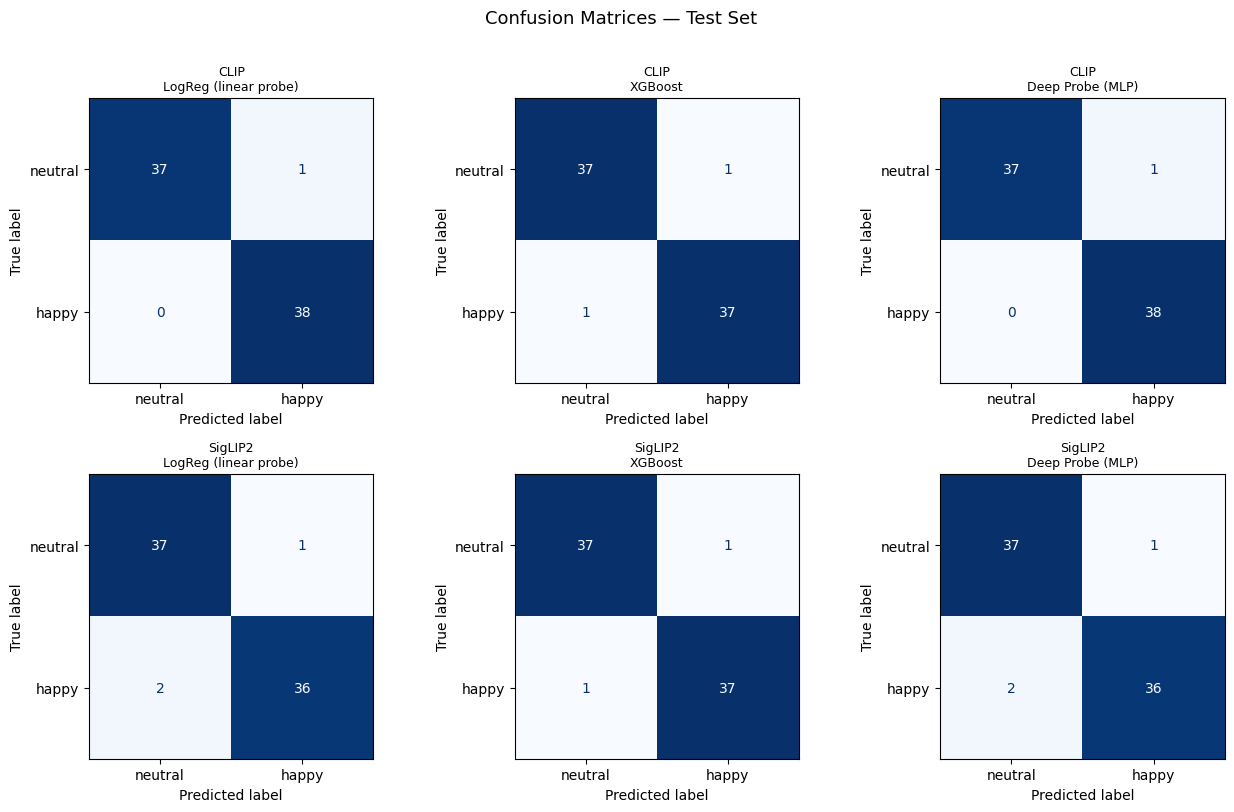

Saved: confusion_matrices.png


In [12]:
# Cell 9: Confusion matrices — 2 × 3 grid (embedding × classifier)

emb_names = list(embedding_sets.keys())   # ["CLIP", "SigLIP2"]
clf_names = list(classifiers.keys())      # 3 classifiers
label_names = ["neutral", "happy"]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for r, emb_name in enumerate(emb_names):
    for c, clf_name in enumerate(clf_names):
        key = f"{emb_name} + {clf_name}"
        clf_fit, X_te = trained_clfs[key]
        y_pred = clf_fit.predict(X_te)
        cm = confusion_matrix(y_test, y_pred)
        ax = axes[r, c]
        ConfusionMatrixDisplay(cm, display_labels=label_names).plot(
            ax=ax, colorbar=False, cmap="Blues"
        )
        ax.set_title(f"{emb_name}\n{clf_name}", fontsize=9)
        if r == 1:
            ax.set_xlabel("Predicted label")
        if c == 0:
            ax.set_ylabel("True label")

plt.suptitle("Confusion Matrices — Test Set", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

Extracting CLIP embeddings for all 500 images...
Extracting SigLIP2 embeddings for all 500 images...
Computing t-SNE projections...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


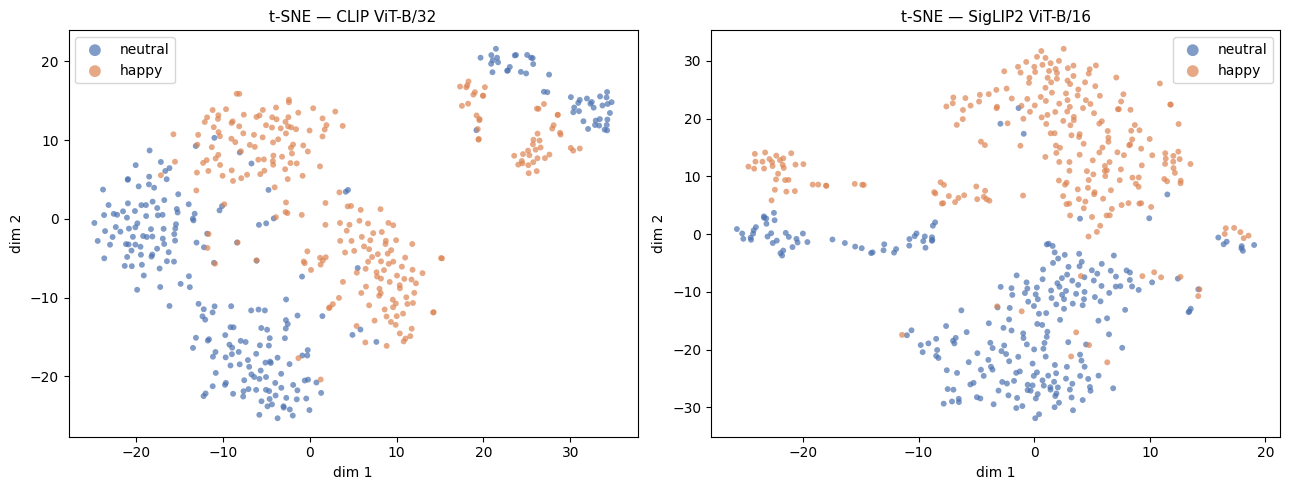

Saved: tsne_comparison.png


In [13]:
# Cell 10: t-SNE — side-by-side for CLIP and SigLIP2 (all 500 images)

print("Extracting CLIP embeddings for all 500 images...")
X_clip_all, y_all = extract_embeddings(df, DATA_DIR, clip_processor, clip_model, "clip", DEVICE)

print("Extracting SigLIP2 embeddings for all 500 images...")
X_sig_all, _ = extract_embeddings(df, DATA_DIR, siglip_processor, siglip_model, "siglip", DEVICE)

print("Computing t-SNE projections...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=SEED)
X_clip_tsne = tsne.fit_transform(X_clip_all)
X_sig_tsne  = tsne.fit_transform(X_sig_all)

COLORS = {0: "#4C72B0", 1: "#DD8452"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, X_2d, title in zip(
    axes,
    [X_clip_tsne, X_sig_tsne],
    ["CLIP ViT-B/32", "SigLIP2 ViT-B/16"],
):
    for label_idx, label_name in enumerate(["neutral", "happy"]):
        mask = y_all == label_idx
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=COLORS[label_idx], label=label_name,
            alpha=0.7, s=18, edgecolors="none",
        )
    ax.set_title(f"t-SNE — {title}", fontsize=11)
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")
    ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig("tsne_comparison.png", dpi=150)
plt.show()
print("Saved: tsne_comparison.png")

Computing UMAP projections...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


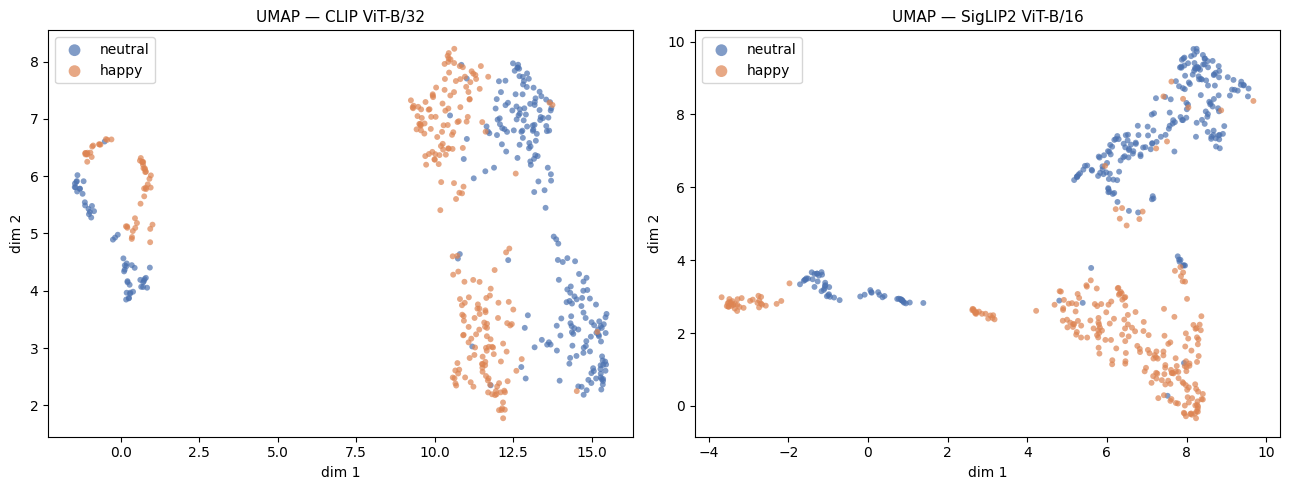

Saved: umap_comparison.png


In [14]:
# Cell 11: UMAP — side-by-side for CLIP and SigLIP2 (all 500 images)

print("Computing UMAP projections...")
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=SEED)
X_clip_umap = reducer.fit_transform(X_clip_all)
X_sig_umap  = reducer.fit_transform(X_sig_all)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, X_2d, title in zip(
    axes,
    [X_clip_umap, X_sig_umap],
    ["CLIP ViT-B/32", "SigLIP2 ViT-B/16"],
):
    for label_idx, label_name in enumerate(["neutral", "happy"]):
        mask = y_all == label_idx
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=COLORS[label_idx], label=label_name,
            alpha=0.7, s=18, edgecolors="none",
        )
    ax.set_title(f"UMAP — {title}", fontsize=11)
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")
    ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig("umap_comparison.png", dpi=150)
plt.show()
print("Saved: umap_comparison.png")

=== Best combination: CLIP + LogReg (linear probe) ===
              precision    recall  f1-score   support

     neutral       1.00      0.97      0.99        38
       happy       0.97      1.00      0.99        38

    accuracy                           0.99        76
   macro avg       0.99      0.99      0.99        76
weighted avg       0.99      0.99      0.99        76



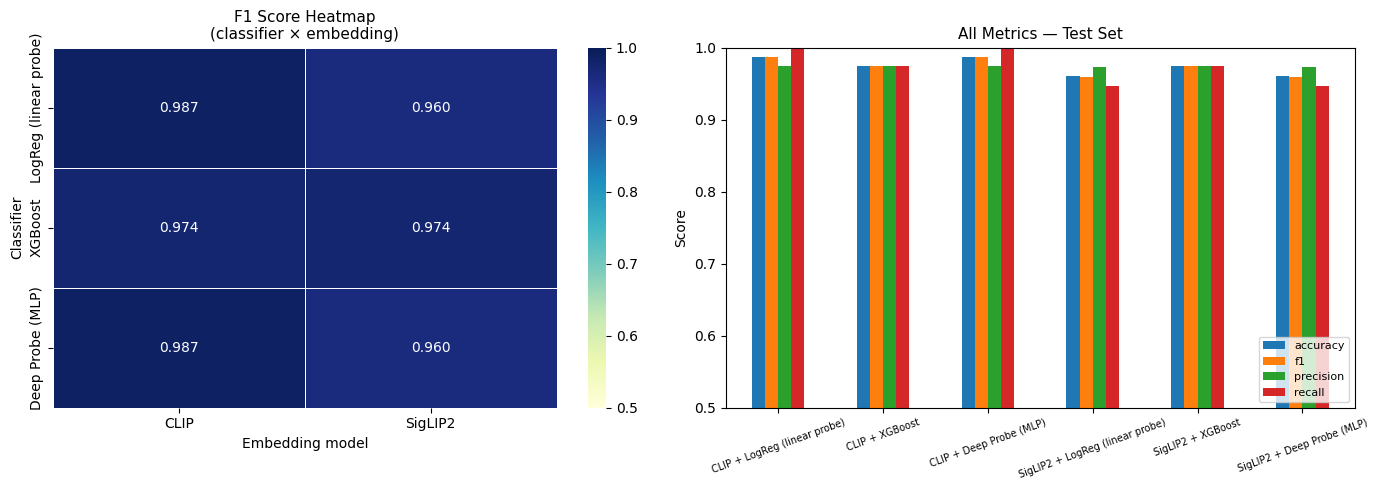

Saved: results_heatmap.png

Done.


In [16]:
# Cell 12: Final report — classification report, heatmap, bar chart

# ── Detailed classification report for best combination ──────────────────────
best_clf_fit, X_te_best = trained_clfs[best_key]
y_pred_best = best_clf_fit.predict(X_te_best)

print(f"=== Best combination: {best_key} ===")
print(classification_report(y_test, y_pred_best, target_names=["neutral", "happy"]))

# ── F1 heatmap: rows = classifiers, columns = embeddings ────────────────────
f1_matrix = pd.DataFrame(
    index=list(classifiers.keys()),
    columns=list(embedding_sets.keys()),
    dtype=float,
)
for emb_name in embedding_sets:
    for clf_name in classifiers:
        key = f"{emb_name} + {clf_name}"
        f1_matrix.loc[clf_name, emb_name] = results[key]["f1"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(
    f1_matrix.astype(float), annot=True, fmt=".3f",
    cmap="YlGnBu", vmin=0.5, vmax=1.0,
    ax=axes[0], linewidths=0.5,
)
axes[0].set_title("F1 Score Heatmap\n(classifier × embedding)", fontsize=11)
axes[0].set_xlabel("Embedding model")
axes[0].set_ylabel("Classifier")

# Bar chart — all 4 metrics for all 6 combinations
metrics = ["accuracy", "f1", "precision", "recall"]
res_plot = pd.DataFrame(results).T[metrics].astype(float)
res_plot.plot(kind="bar", ax=axes[1], ylim=(0.5, 1.0), rot=20)
axes[1].set_title("All Metrics — Test Set", fontsize=11)
axes[1].set_ylabel("Score")
axes[1].legend(loc="lower right", fontsize=8)
axes[1].tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.savefig("results_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results_heatmap.png")
print("\nDone.")

In [ ]:
# Cell 13: Save best model to Google Drive
import pickle

MODEL_DIR = Path("/content/gdrive/MyDrive/AffectiveComputing/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_clf_fit, _ = trained_clfs[best_key]
model_artifact = {
    "model": best_clf_fit,
    "best_key": best_key,
    "label_map": LABEL_MAP,
}

safe_name = best_key.lower().replace(" + ", "__").replace(" ", "_").replace("(", "").replace(")", "")
model_path = MODEL_DIR / f"best_model_{safe_name}.pkl"

with open(model_path, "wb") as f:
    pickle.dump(model_artifact, f)

print(f"Saved best model to: {model_path}")